### Legal Document Classification with Supervised Machine Learning Algorithms

The aim of this notebook is to determine most suitable model for the classification of Greek legal documents. The experiments are conducted using the Greek Legal Code dataset from the National and Kapodistrian University of Athens (NKUA), available on Hugging Face. The dataset contains the same collection of legal documents with different labels assigned to each. In other words, each document is annotated with three hierarchical labels: **Collection, Chapter, and Subject**.

The primary goal is to predict these labels based solely on the document's text with the best possible scores. To accomplish this, several supervised machine learning algorithms are tested and compared using different vecorization and embedding techiques.


**Dataset available at __[huggingface](https://huggingface.co/datasets/AI-team-UoA/greek_legal_code)__**


**Note: Data is already split into 1) train data 2) test data 3) validation sets**

### Exploratory Data Analysis

**Imports**

In [69]:
# %pip install gensim

In [ ]:
# Imports
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import gzip
import shutil
from gensim.models import KeyedVectors
from pathlib import Path
from urllib.request import urlretrieve
from gensim.models import Word2Vec
from nltk.tokenize import sent_tokenize, word_tokenize
import time
import xgboost as xgb
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [ ]:
def load_dataframe(subset):
    original_path = "hf://datasets/AI-team-UoA/greek_legal_code/"
    splits = {
        'train': f"{original_path}{subset}/train-00000-of-00001.parquet",
        'validation': f"{original_path}{subset}/validation-00000-of-00001.parquet",
        'test': f"{original_path}{subset}/test-00000-of-00001.parquet"
    }
    train = pd.read_parquet(splits["train"])
    test = pd.read_parquet(splits["test"])
    validation = pd.read_parquet(splits["validation"])
    return train, test, validation

In [ ]:
subcategories = ["chapter", "volume", "subject"]

for subcategory in subcategories:
    train, test, validation = load_dataframe(subcategory)

    class_count = train["label"].value_counts()

    print(f"\nfor subcategory {subcategory}\n")

    print("Num of classes:", len(class_count))
    print("Minimum documents per class:", class_count.min())
    print("Maximum documents per class:", class_count.max())
    print("Median documents per class:", class_count.median())

    print("Classes with 1 doc:", (class_count == 1).sum())
    print("Classes with < 3 docs:", (class_count < 3).sum())
    print("Classes with < 5 docs:", (class_count < 5).sum())
    print("Classes with < 10 docs:", (class_count < 10).sum())
    print("Classes with >10 and < 50 docs:", ((class_count < 50)& (class_count > 10)).sum())


for subcategory chapter

Num of classes: 386
Minimum documents per class: 1
Maximum documents per class: 788
Median documents per class: 50.0
Classes with 1 doc: 10
Classes with < 3 docs: 13
Classes with < 5 docs: 24
Classes with < 10 docs: 51
Classes with >10 and < 50 docs: 139

for subcategory volume

Num of classes: 47
Minimum documents per class: 142
Maximum documents per class: 2095
Median documents per class: 508.0
Classes with 1 doc: 0
Classes with < 3 docs: 0
Classes with < 5 docs: 0
Classes with < 10 docs: 0
Classes with >10 and < 50 docs: 0

for subcategory subject

Num of classes: 2143
Minimum documents per class: 1
Maximum documents per class: 793
Median documents per class: 6.0
Classes with 1 doc: 345
Classes with < 3 docs: 586
Classes with < 5 docs: 910
Classes with < 10 docs: 1375
Classes with >10 and < 50 docs: 600


#### Class Distribution and Potential challenges ####

The target variables show substantially different levels of granularity and class imbalance.
- Volume : most balanced, thus might produce the best classification scores, containing only 47 classes with at least 142 documents per class and a median of 508. Therefore, there are sufficient training examples to obtain good accuracy per class.

 - Chapter : challenging distribution, with 386 classes and a median of 50 documents per class. While most classes contain a reasonable number of observations, 51 classes have fewer than 10 documents and 10 are represented by only a single document. This imbalance may reduce the model's ability to correctly classify future documents.

 - Subject : very low number of training material per class, as it contains 2,143 unique classes but has a median of only 6 documents per class. In particular, 345 classes contain a single training document, while 1,375 classes contain fewer than 10. This represents a strong long-tail distribution, meaning a relatively small number of classes have many observations while a large proportion are severely underrepresented.This imbalance may reduce the model's ability to correctly classify future documents.


### Linear classifiers

#### 1. Support Vector Machines (SVM) with vectorization techniques: Bag-of-Words (BoW) and TF-IDF representation.

Support Vector Machines (SVM) are first trained and evaluated using two sparse text representations: Bag-of-Words and TF-IDF which preserve information about individual terms in each document, making them particularly useful for legal text. Specific terminology and recurring expressions can be strong indicators of a legal document's category.

BoW uses raw term frequencies, while TF-IDF is a balanced approach, uses additional weights terms according to their importance across the corpus, meaning it highlights terms that are both frequent within a specific document and distinctive across the text document

<div class=" alert alert-block alert-info">
    <b> Note: Some labels are present in the test subset but absent from the train subset. filtering will be used.</b>
</div>

In [ ]:
def build_vectorized_dataset(train, test, vectorizer):

    # fit vetorizer on train/test
    X_train = vectorizer.fit_transform(train["text"])

    X_test = vectorizer.transform(test["text"])

    # encode training labels
    label_encoder = LabelEncoder()

    Y_train = label_encoder.fit_transform(train["label"])

    # keep  only labels known from training
    known_labels = set(train["label"])

    test_filtered = test[test["label"].isin(known_labels)]

    test_positions = test.index.get_indexer(test_filtered.index)
    X_test_filtered = X_test[test_positions]

    Y_test_filtered = label_encoder.transform(test_filtered["label"])

    return (
        X_train,
        Y_train,
        X_test_filtered,
        Y_test_filtered,
    )

In [ ]:
# Traininig SVM
def svm_model(X_train, Y_train, X_test, Y_test):
    model = make_pipeline(
        MaxAbsScaler(),  # Scales sparse counts into [0, 1] without destroying zeros
        SGDClassifier(
            loss="hinge",
            penalty="l2",
            alpha=1e-5,
            max_iter=1000,
            tol= 1e-3,
            early_stopping=False,
            n_jobs=-1,
            random_state=42,
        ),
    )

    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)
    return Y_pred

In [ ]:
results = []

In [ ]:
def calculate_scores(y_test, y_pred, subcategory):
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

        print(f"\nReport for category {subcategory} : \n ")
        print(f"Accuracy : {accuracy:.3f}")
        print(f"Precision: {precision:.3f}")
        print(f"Recall   : {recall:.3f}")
        print(f"F1-score : {f1:.3f}")

        return accuracy

In [ ]:
# CountVectorizer from sklearn will be used for BOW : builds a vocabulary of the top (10,000 -> as specified) most frequent words across the training data.

**Training Support Vector Machine (using BOW)**

BoW key points:
   -  Converts text into a collection of words
   -  Counts how often each word appears in the text (frequency)

There are 390 distinct classes (0 to 388) for just one subcategory. This drastically increases the computation of the algorithm, because scikit-learn's LinearSVC defaults to a One-vs-Rest strategy, training LinearSVC on this single subcategory forces it to fit nearly 390 separate binary classifiers, each solving an optimization problem across dataset. This comlexity increases, since it has to be performed 3 times.

In [ ]:
accuracies = classifier(svm_model, "bow")

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.556
Precision: 0.595
Recall   : 0.556
F1-score : 0.554
Training for: volume

Report for category volume : 
 
Accuracy : 0.664
Precision: 0.672
Recall   : 0.664
F1-score : 0.658
Training for: subject

Report for category subject : 
 
Accuracy : 0.412
Precision: 0.476
Recall   : 0.412
F1-score : 0.408


In [ ]:
def classifier( classifier_function, embedding_type, model = None, embedding_function = None):
    subcategories = ["chapter", "volume", "subject"]
    accuracies = {}
    for subcategory in subcategories:
        print(f"Training for: {subcategory}")

        train, test, validation = load_dataframe(subcategory)

        match embedding_type:
            case "idf":
                vectorizer = idf_vectorizer(train, test)

                X_train, Y_train, X_test, Y_test = (
                    build_embedding_dataset(
                        train, test,
                        model,
                        embedding_function,
                        tfidf_vectorizer=vectorizer
                    )
                )

            case "mean":
                X_train, Y_train, X_test, Y_test = (build_embedding_dataset(train, test, model, embedding_function))

            case "bow":
                vectorizer = CountVectorizer(max_features=10000,min_df=2)
                X_train, Y_train, X_test, Y_test = build_vectorized_dataset(train, test, vectorizer)

            case "idf_vector":
                vectorizer = idf_vectorizer(train,test)
                X_train, Y_train, X_test, Y_test = build_vectorized_dataset(train, test, vectorizer)

            case _:
                raise ValueError(f"unknown embedding type: {embedding_type}")

        Y_pred = classifier_function(
            X_train,
            Y_train,
            X_test,
            Y_test
        )
        accuracy = calculate_scores(Y_test, Y_pred, subcategory)
        # adding key-value pair
        accuracies[subcategory] = accuracy

    return accuracies

In [ ]:
results.append({
    "Classifier": "SVM",
    "Representation": "BOW",
    **accuracies
})

**Training Support Vector Machine (using TF-IDF)**

In [ ]:
def idf_vectorizer(train, test):
    tfidf_vectorizer = TfidfVectorizer(max_features=10000)
    X_train_tfidf = tfidf_vectorizer.fit_transform(train["text"])
    X_test_tfidf = tfidf_vectorizer.transform(test["text"])

    return tfidf_vectorizer

In [ ]:
accuracies = classifier(svm_model, "idf_vector")

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.711
Precision: 0.725
Recall   : 0.711
F1-score : 0.710
Training for: volume

Report for category volume : 
 
Accuracy : 0.785
Precision: 0.788
Recall   : 0.785
F1-score : 0.785
Training for: subject

Report for category subject : 
 
Accuracy : 0.590
Precision: 0.639
Recall   : 0.590
F1-score : 0.589


In [ ]:
results.append({
    "Classifier": "SVM",
    "Representation": "TF-IDF",
    **accuracies
})

#### 2. Support Vector Machines (SVM) with Dense Embeddings (Word2Vec and FastText embeddings)

To attempt and optimize the results of classification, the same classifiers will be additionally tested with Dense embeddings. Unlike BoW and TF-IDF, Word2Vec and FastText produce dense vector representations. Dense embeddings learn a low-dimensional vector of continuous values for each word by optimizing a neural network to predict **linguistic context**, causing words with similar meanings or usage to have similar vector representations.

#### Word2Vec

Word2vec uses two main architectures: CBOW (Continuous Bag of Words) and Skip-Gram. The model will be trained on data of this dataset instead of greek vocabulary, since the text is heavy on Legal Terminology.

**Mean pooling**: averages all available word vectors to produce a single document embedding.

In [ ]:
def dense_embed_text(text, model):
    words = text.lower().split()

    # Word2Vec stores vectors in model.wv
    # whereas FastText KeyedVectors store vectors directly in model
    if hasattr(model, "wv"):
        vectors_model = model.wv
    else:
        vectors_model = model

    word_vectors = [
        vectors_model[word]
        for word in words
        if word in vectors_model
    ]

    if not word_vectors:
        return np.zeros(vectors_model.vector_size)

    return np.mean(word_vectors, axis=0)

**TF-IDF-weighted pooling:** weights each word vector according to its TF-IDF importance, giving more influence to terms that are more informative within the document.

In [ ]:
def dense_embed_idf(text, model, tfidf_vectorizer):
    if hasattr(model, "wv"):
        vectors_model = model.wv
    else:
        vectors_model = model

    words = text.lower().split()

    # Create the TF-IDF representation for this document
    tfidf_row = tfidf_vectorizer.transform([text])

    # Get the vocabulary terms learned by the vectorizer
    feature_names = tfidf_vectorizer.get_feature_names_out()

    # Match each word in this document with tbe according tf-idf weight
    tfidf_weights = {
        feature_names[idx]: weight
        for idx, weight in zip(tfidf_row.indices, tfidf_row.data)
    }

    weighted_sum = np.zeros(vectors_model.vector_size, dtype=np.float32)
    total_weight = 0.0

    for word in words:
        if word in vectors_model and word in tfidf_weights:
            weight = tfidf_weights[word]
            weighted_sum += weight * vectors_model[word]
            total_weight += weight

    if total_weight == 0:
        return np.zeros(model.vector_size, dtype=np.float32)

    return weighted_sum / total_weight

Corpus fo Training Word2vec model on the data of current datase

In [ ]:
class SentenceCorpus:
    def __init__(self, texts):
        self.texts = texts

    def __iter__(self):
        for text in self.texts:
            # check if text exists
            if not isinstance(text, str):
                continue

            # start_time = time.perf_counter()


            for sentence in sent_tokenize(text):
                tokens = [word.lower() for word in word_tokenize(sentence) if word.strip()]

                if tokens:
                    yield tokens

            # print(time.perf_counter() - start_time)

Word2vec model is unsupervised and since the "text" content in all 3 chapters remains the same, therefore the model will be trained on one model

In [ ]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
train, test, validation = load_dataframe("chapter")

corpus = SentenceCorpus(train["text"])

model = Word2Vec(
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    sg=0
)

# 1st pass: building vocabulary
model.build_vocab(corpus)

# 2nd pass: train
model.train(
    corpus,
    total_examples=model.corpus_count,
    epochs=model.epochs
)

(74732917, 101738775)

In [ ]:
def build_embedding_dataset(train, test, model,embedding_function, **embedding_kwargs):

    X_train = np.vstack(train['text'].apply(lambda x: embedding_function(x, model, **embedding_kwargs)))
    X_test = np.vstack(test['text'].apply(lambda x: embedding_function(x, model, **embedding_kwargs)))

    # label encoding
    label_encoder = LabelEncoder()
    Y_train = label_encoder.fit_transform(train['label'])

    # filter labels
    known_labels = set(train['label'])
    test_filtered = test[test['label'].isin(known_labels)]

    Y_test_filtered = label_encoder.transform(test_filtered['label'])

    # filter X_test accordingly
    X_test_filtered = X_test[test_filtered.index]

    return (
        X_train,
        Y_train,
        X_test_filtered,
        Y_test_filtered,
    )

**SVM using Word2vec + mean pooling technique**

In [22]:
accuracies = classifier( svm_model, "mean", model, dense_embed_text)

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.349
Precision: 0.501
Recall   : 0.349
F1-score : 0.353
Training for: volume

Report for category volume : 
 
Accuracy : 0.463
Precision: 0.544
Recall   : 0.463
F1-score : 0.464
Training for: subject

Report for category subject : 
 
Accuracy : 0.231
Precision: 0.359
Recall   : 0.231
F1-score : 0.234


In [23]:
results.append({
    "Classifier": "SVM",
    "Representation": "Word2vec + mean",
    **accuracies
})

**SVM using Word2vec + tf-idf representation**

In [24]:
accuracies = classifier( svm_model, "idf", model, dense_embed_idf)

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.328
Precision: 0.464
Recall   : 0.328
F1-score : 0.326
Training for: volume

Report for category volume : 
 
Accuracy : 0.419
Precision: 0.556
Recall   : 0.419
F1-score : 0.452
Training for: subject

Report for category subject : 
 
Accuracy : 0.231
Precision: 0.363
Recall   : 0.231
F1-score : 0.240


In [25]:
results.append({
    "Classifier": "SVM",
    "Representation": "Word2vec + idf",
    **accuracies
})

### FastText pre-trained model ###

FastText is next for testing, as it is a more optimised version than Word2vec. The neural network itself between word2vec and fast text remains almost identical. The key innovation is that instead of representing each word as a single index in the vocabulary, FastText represents it as a set of character n-grams. This enables it to generate meaningful embeddings for rare and unseen words more effectively than traditional word embedding methods.


*  since it computationally demanding to train fasttext on this data, an existing greek model will be used



The neural network itself between word2vec and fast text remains almost identical. The key innovation is that instead of representing each word as a single index in the vocabulary, FastText represents it as a set of character n-grams.

Embeddings can be found here https://fasttext.cc/docs/en/crawl-vectors.html

In [26]:
# script to download and uzip fast Text model in the current working directory

In [27]:
greek_model_url = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.el.300.vec.gz"

zip_path = Path.home() / "cc.el.300.vec.gz"
vec_path = Path.home() / "cc.el.300.vec"

if not vec_path.exists():
    print("Downloading ...")
    urlretrieve(greek_model_url, zip_path)
    print("Download completed")

    print("Unzipping")    #
    with gzip.open(zip_path, 'rb') as f_in:
        with open(vec_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

    zip_path.unlink()

else:
    print("Model already exists.")

Download completed
Unzipping


In [28]:
fasttext_model = KeyedVectors.load_word2vec_format(vec_path, encoding="utf-8")

In [63]:
accuracies = classifier( svm_model, "mean", fasttext_model, dense_embed_text)

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.359
Precision: 0.541
Recall   : 0.359
F1-score : 0.357
Training for: volume

Report for category volume : 
 
Accuracy : 0.509
Precision: 0.617
Recall   : 0.509
F1-score : 0.517
Training for: subject

Report for category subject : 
 
Accuracy : 0.236
Precision: 0.406
Recall   : 0.236
F1-score : 0.245


In [64]:
results.append({
    "Classifier": "SVM",
    "Representation": "FastText + mean",
    **accuracies
})

In [66]:
accuracies = classifier( svm_model, "idf", fasttext_model, dense_embed_idf)

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.351
Precision: 0.537
Recall   : 0.351
F1-score : 0.359
Training for: volume

Report for category volume : 
 
Accuracy : 0.455
Precision: 0.584
Recall   : 0.455
F1-score : 0.463
Training for: subject

Report for category subject : 
 
Accuracy : 0.230
Precision: 0.393
Recall   : 0.230
F1-score : 0.243


In [67]:
results.append({
    "Classifier": "SVM",
    "Representation": "FastText + idf",
    **accuracies
})

### 2. Logistic Regression ###

Anoher Linear classifier(Logistic Regression) will be trained with the same models/ representations as before

In [34]:
def logistic_regr_model(X_train, Y_train, X_test, Y_test):
    model = make_pipeline(
        MaxAbsScaler(),
        SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=1e-5,
            max_iter=1000,
            tol=1e-3,
            n_jobs=-1,
            random_state=42
        )
    )

    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    return Y_pred

**Logistic Regression using LR + BOW**

In [35]:
accuracies = classifier(logistic_regr_model, "bow")

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.332
Precision: 0.521
Recall   : 0.332
F1-score : 0.325
Training for: volume

Report for category volume : 
 
Accuracy : 0.523
Precision: 0.606
Recall   : 0.523
F1-score : 0.508
Training for: subject

Report for category subject : 
 
Accuracy : 0.200
Precision: 0.339
Recall   : 0.200
F1-score : 0.195


In [36]:
results.append({
    "Classifier": "LR",
    "Representation": "BOW",
    **accuracies
})

**Logistic Regression using LR + TF-IDF**

In [37]:
accuracies = classifier(logistic_regr_model, "idf_vector")

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.735
Precision: 0.744
Recall   : 0.735
F1-score : 0.728
Training for: volume

Report for category volume : 
 
Accuracy : 0.813
Precision: 0.816
Recall   : 0.813
F1-score : 0.812
Training for: subject

Report for category subject : 
 
Accuracy : 0.611
Precision: 0.621
Recall   : 0.611
F1-score : 0.585


In [38]:
results.append({
    "Classifier": "SVM",
    "Representation": "TF-IDF",
    **accuracies
})

**Logistic Regression using Word2vec + mean pooling technique**

In [39]:
accuracies = classifier( logistic_regr_model, "mean", model, dense_embed_text)

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.357
Precision: 0.502
Recall   : 0.357
F1-score : 0.363
Training for: volume

Report for category volume : 
 
Accuracy : 0.491
Precision: 0.535
Recall   : 0.491
F1-score : 0.476
Training for: subject

Report for category subject : 
 
Accuracy : 0.258
Precision: 0.376
Recall   : 0.258
F1-score : 0.256


In [40]:
results.append({
    "Classifier": "LR",
    "Representation": "Word2vec + mean",
    **accuracies
})

**Logistic Regression using Word2vec + tf-idf**

In [41]:
accuracies = classifier(logistic_regr_model, "idf", model, dense_embed_idf)

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.350
Precision: 0.496
Recall   : 0.350
F1-score : 0.359
Training for: volume

Report for category volume : 
 
Accuracy : 0.477
Precision: 0.545
Recall   : 0.477
F1-score : 0.477
Training for: subject

Report for category subject : 
 
Accuracy : 0.257
Precision: 0.373
Recall   : 0.257
F1-score : 0.261


In [42]:
results.append({
    "Classifier": "LR",
    "Representation": "Word2vec + idf",
    **accuracies
})

**Logistic Regression using FastText + mean pooling technique**

In [43]:
accuracies = classifier(logistic_regr_model, "mean", fasttext_model, dense_embed_text)

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.390
Precision: 0.545
Recall   : 0.390
F1-score : 0.389
Training for: volume

Report for category volume : 
 
Accuracy : 0.524
Precision: 0.603
Recall   : 0.524
F1-score : 0.519
Training for: subject

Report for category subject : 
 
Accuracy : 0.279
Precision: 0.390
Recall   : 0.279
F1-score : 0.277


In [44]:
results.append({
    "Classifier": "LR",
    "Representation": "FastText + mean",
    **accuracies
})

**Logistic Regression using FastText + TF-idf**

In [45]:
accuracies = classifier(logistic_regr_model, "idf", fasttext_model, dense_embed_idf)

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.344
Precision: 0.522
Recall   : 0.344
F1-score : 0.352
Training for: volume

Report for category volume : 
 
Accuracy : 0.471
Precision: 0.558
Recall   : 0.471
F1-score : 0.464
Training for: subject

Report for category subject : 
 
Accuracy : 0.258
Precision: 0.373
Recall   : 0.258
F1-score : 0.254


In [46]:
results.append({
    "Classifier": "LR",
    "Representation": "FastText + idf",
    **accuracies
})

### Tree classifiers ###

A tree classifier will be tested. For this complexity and volume of classes, XGboost is selected as the tree classifier. Although computationally demanding, it could possibly lead to a good accuracy score.

key benefits:
is an

*   optimized gradient boosting algorithm that combines multiple weak models   into a stronger, high-performance model
*   uses decision trees as base learners, building them sequentially so each tree corrects errors from the previous (boosting)
*   features parallel processing for faster training on large datasets


In [ ]:
# %pip install xgboost

In [47]:
def xgboost_model(X_train, Y_train, X_test, Y_test):
    num_classes = len(np.unique(Y_train))

    matrix_train = xgb.QuantileDMatrix(
        X_train,
        label=Y_train,
        max_bin=64
    )

    matrix_test = xgb.QuantileDMatrix(
        X_test,
        ref=matrix_train,
        max_bin=64
    )

    params = {
        "objective": "multi:softprob",
        "num_class": num_classes,

        "tree_method": "hist",

        "max_depth": 3,
        "max_bin": 64,

        "eta": 0.1,

        "subsample": 0.6,
        "colsample_bytree": 0.5,

        "min_child_weight": 5,

        "eval_metric": "mlogloss",
        "nthread": 2
    }

    bst = xgb.train(params, matrix_train, num_boost_round=30)

    probabilities = bst.predict(matrix_test)

    Y_pred = np.argmax(probabilities,axis=1)

    return Y_pred

**XGboost using BOW**

In [48]:
accuracies = classifier(xgboost_model, "bow")

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.441
Precision: 0.381
Recall   : 0.441
F1-score : 0.379
Training for: volume

Report for category volume : 
 
Accuracy : 0.642
Precision: 0.671
Recall   : 0.642
F1-score : 0.636
Training for: subject

Report for category subject : 
 
Accuracy : 0.193
Precision: 0.125
Recall   : 0.193
F1-score : 0.128


In [49]:
results.append({
    "Classifier": "XGboost",
    "Representation": "BOW",
    **accuracies
})

**XGboost using IDF**

In [51]:
accuracies = classifier(xgboost_model, "idf_vector")

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.472
Precision: 0.413
Recall   : 0.472
F1-score : 0.415
Training for: volume

Report for category volume : 
 
Accuracy : 0.672
Precision: 0.696
Recall   : 0.672
F1-score : 0.669
Training for: subject

Report for category subject : 
 
Accuracy : 0.213
Precision: 0.146
Recall   : 0.213
F1-score : 0.150


In [52]:
results.append({
    "Classifier": "XGboost",
    "Representation": "TF-IDF",
    **accuracies
})

**XGboost using Word2Vec + mean pooling**

In [53]:
accuracies = classifier(xgboost_model, "mean", model, dense_embed_text)

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.252
Precision: 0.254
Recall   : 0.252
F1-score : 0.214
Training for: volume

Report for category volume : 
 
Accuracy : 0.323
Precision: 0.362
Recall   : 0.323
F1-score : 0.294
Training for: subject

Report for category subject : 
 
Accuracy : 0.142
Precision: 0.137
Recall   : 0.142
F1-score : 0.108


In [54]:
results.append({
    "Classifier": "XGboost",
    "Representation": "Word2vec + mean",
    **accuracies
})

**XGboost using Word2Vec + TF-IDF**

In [56]:
accuracies = classifier(xgboost_model, "idf", model, dense_embed_idf)

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.254
Precision: 0.260
Recall   : 0.254
F1-score : 0.219
Training for: volume

Report for category volume : 
 
Accuracy : 0.336
Precision: 0.371
Recall   : 0.336
F1-score : 0.308
Training for: subject

Report for category subject : 
 
Accuracy : 0.148
Precision: 0.151
Recall   : 0.148
F1-score : 0.117


In [57]:
results.append({
    "Classifier": "XGboost",
    "Representation": "Word2vec + idf",
    **accuracies
})

**XGboost using FastText + mean pooling**

In [58]:
accuracies = classifier(xgboost_model, "mean", fasttext_model, dense_embed_text)

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.224
Precision: 0.234
Recall   : 0.224
F1-score : 0.188
Training for: volume

Report for category volume : 
 
Accuracy : 0.301
Precision: 0.330
Recall   : 0.301
F1-score : 0.268
Training for: subject

Report for category subject : 
 
Accuracy : 0.126
Precision: 0.140
Recall   : 0.126
F1-score : 0.100


In [59]:
results.append({
    "Classifier": "XGboost",
    "Representation": "FastText + mean",
    **accuracies
})

**XGboost using FastText + TF-IDF**

In [60]:
accuracies = classifier(xgboost_model, "idf", fasttext_model, dense_embed_idf)

Training for: chapter

Report for category chapter : 
 
Accuracy : 0.238
Precision: 0.260
Recall   : 0.238
F1-score : 0.206
Training for: volume

Report for category volume : 
 
Accuracy : 0.325
Precision: 0.392
Recall   : 0.325
F1-score : 0.298
Training for: subject

Report for category subject : 
 
Accuracy : 0.138
Precision: 0.146
Recall   : 0.138
F1-score : 0.111


In [61]:
results.append({
    "Classifier": "XGboost",
    "Representation": "FastText + idf",
    **accuracies
})

### Visualizing and Evaluating Results

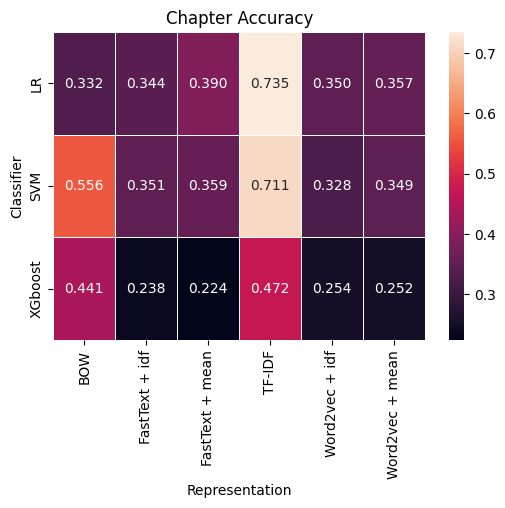

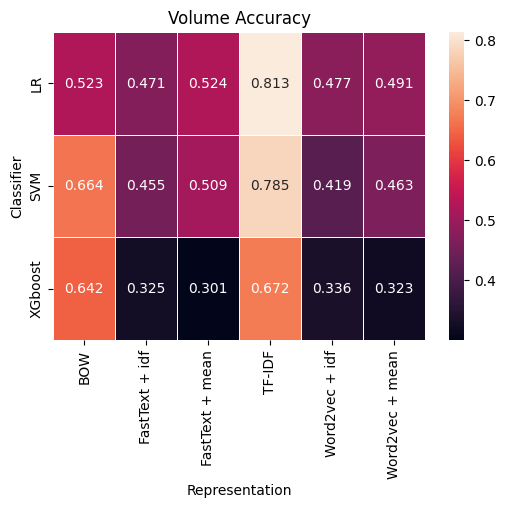

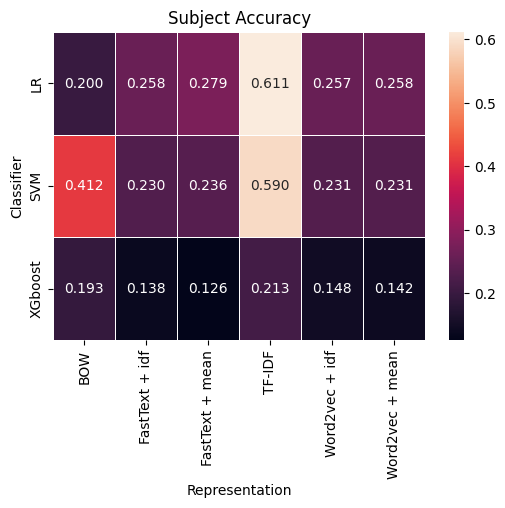

In [70]:
results_df = pd.DataFrame(results)
(results_df)
import matplotlib.pyplot as plt
import seaborn as sns

wrong_label = (
    (results_df["Classifier"] == "SVM") &
    (results_df["Representation"] == "TF-IDF") &
    np.isclose(results_df["chapter"].astype(float), 0.735177)
)

# Correct only its classifier name
results_df.loc[wrong_label, "Classifier"] = "LR"
results_df = results_df.drop_duplicates(
    subset=["Classifier", "Representation"],
    keep="last"
)

# heatmap for each chapter
for category in ["chapter", "volume", "subject"]:

    heatmap_data = results_df.pivot(
        index="Classifier",
        columns="Representation",
        values=category
    )

    heatmap_data = heatmap_data.apply(
        pd.to_numeric,
        errors="coerce"
    )

    plt.figure(figsize=(6, 4))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        linewidths=0.5
    )

    plt.title(f"{category.capitalize()} Accuracy")
    plt.xlabel("Representation")
    plt.ylabel("Classifier")

    plt.show()

### Results

* **Linear classifiers perform best with TF-IDf** representation which could be
  attributed to its balanced approach that takes into account rare legal terminology as well as frequent words obtained from text.

 * Highest **accuracy of approximately 81% is achieved for Volume** due to LR + TF-IDF combination, which was expected as for all classifiers, volume is the simplest classification case.

 * However, the same combination also achieves **the best accuracy (61%)** for the nuanced **Subject chapter that contains over 2000 highly imbalanced classes**


* BoW remains competitive, especially for volume, while dense embeddings perform considerably worse

* WordVec performed poorly in comparison to sparse representation. Averaging word vectors likely removes important word-level signals that TF-IDF preserves. The results indicate that, for this dataset, term importance is more useful for distinguishing legal categories than the broader semantic similarity captured by Word2Vec.

* Overall, FastText underperforms across all chapters, especially unusual for volume. A model trained on the whole greek vocabulary might not be a match for this case as it may not capture specialized Greek legal terminology.

* XGBoost performs reasonably with TF-IDF and BoW but struggles with FastText and Word2Vec. This suggests that the pooled dense vectors do not provide sufficiently discriminative features for tree-based classification.